In [24]:
import pandas as pd

df = pd.read_csv('movie_recommendation_dataset.csv')
df.head(5)

,Age,HoursPerWeek,MoviesLastMonth,Gender,FavoriteGenre,Subscription,RecommendGroup
0,NaN,27,18,Female,Sci-Fi,Standard,GroupA
1,NaN,24,16,Other,Romance,Premium,GroupA
2,43.0,38,19,Other,Comedy,Basic,GroupB
3,29.0,32,9,Female,Romance,Basic,GroupB
4,57.0,0,5,NaN,Sci-Fi,Standard,GroupC


In [25]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 210 entries, 0 to 209
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Age              189 non-null    float64
 1   HoursPerWeek     210 non-null    int64  
 2   MoviesLastMonth  210 non-null    int64  
 3   Gender           190 non-null    object 
 4   FavoriteGenre    188 non-null    object 
 5   Subscription     210 non-null    object 
 6   RecommendGroup   210 non-null    object 
dtypes: float64(1), int64(2), object(4)
memory usage: 11.6+ KB


In [26]:
print("Rows, Columns:\n", df.isnull().sum())

Rows, Columns:
 Age                21
HoursPerWeek        0
MoviesLastMonth     0
Gender             20
FavoriteGenre      22
Subscription        0
RecommendGroup      0
dtype: int64


In [27]:
print("Duplicates\n", df.duplicated().sum())

Duplicates
 10


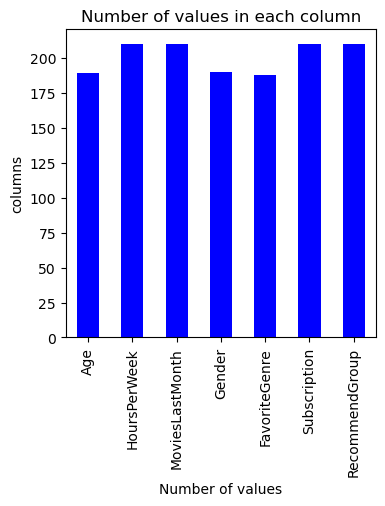

In [28]:
import matplotlib.pyplot as plt

valueParColumn = df.notnull().sum()

plt.figure(figsize=(4,4))
valueParColumn.plot(kind='bar', color='blue')
plt.title("Number of values in each column")
plt.xlabel("Number of values")
plt.ylabel("columns")
plt.show()

In [29]:
categorical_cols = df.select_dtypes(include=['object']).columns.to_list()
categorical_cols.remove('RecommendGroup')
numerical_cols = df.select_dtypes(include=['float64', 'int64']).columns.to_list()

In [30]:
categorical_cols

['Gender', 'FavoriteGenre', 'Subscription']

In [31]:
df[numerical_cols] = df[numerical_cols].fillna(df[numerical_cols].mean())

In [32]:
for col in categorical_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

In [33]:
from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
X_cat = encoder.fit_transform(df[categorical_cols])
X_cat_df = pd.DataFrame(X_cat, columns=encoder.get_feature_names_out(categorical_cols))


In [35]:
X = pd.concat([df[numerical_cols].reset_index(drop=True), X_cat_df.reset_index(drop=True)], axis=1)


In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['RecommendGroup'] = le.fit_transform(df['RecommendGroup'])

In [36]:
from sklearn.model_selection import train_test_split

#x = df.drop('RecommendGroup', axis=1)
y = df['RecommendGroup']

x_train, x_test, y_train, y_test = train_test_split(
    X, y, train_size=0.8, test_size=0.2, random_state=42
)


In [ ]:
y.head(3)

0    0
1    0
2    1
Name: RecommendGroup, dtype: int64

In [37]:
from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier()
model.fit(x_train, y_train)

y_pred = model.predict(x_test)

In [38]:
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report

print("Decision Tree Accuricy:\n", accuracy_score(y_test, y_pred))
print("Descision Tree classification\n", classification_report(y_test, y_pred))
print("Descision Tree confusion metrix\n", confusion_matrix(y_test, y_pred))

Decision Tree Accuricy:
 0.4523809523809524
Descision Tree classification
               precision    recall  f1-score   support

      GroupA       0.83      0.29      0.43        17
      GroupB       0.50      0.67      0.57        15
      GroupC       0.25      0.40      0.31        10

    accuracy                           0.45        42
   macro avg       0.53      0.45      0.44        42
weighted avg       0.58      0.45      0.45        42

Descision Tree confusion metrix
 [[ 5  4  8]
 [ 1 10  4]
 [ 0  6  4]]


In [39]:
from sklearn.ensemble import RandomForestClassifier
model = RandomForestClassifier()
model.fit(x_train, y_train)

y_pred2 = model.predict(x_test)

In [40]:
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report

print("Random Forest Accuricy:\n", accuracy_score(y_test, y_pred2))
print("Random Forest classification\n", classification_report(y_test, y_pred2))
print("Random Forest confusion metrix\n", confusion_matrix(y_test, y_pred2))

Random Forest Accuricy:
 0.2619047619047619
Random Forest classification
               precision    recall  f1-score   support

      GroupA       0.27      0.24      0.25        17
      GroupB       0.45      0.33      0.38        15
      GroupC       0.12      0.20      0.15        10

    accuracy                           0.26        42
   macro avg       0.28      0.26      0.26        42
weighted avg       0.30      0.26      0.28        42

Random Forest confusion metrix
 [[4 5 8]
 [4 5 6]
 [7 1 2]]
